In [57]:
# Imports
import pandas as pd
import re
import matplotlib.pyplot as plt
import datetime

In [100]:
# Plot average time per epoch
def plot_avg_time_per_epoch(file_path, title):
    timestamp_pattern = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) \| INFO \| epoch: (\d+)')

    epoch_times = {}

    with open(file_path, 'r') as file:
        for line in file:
            match = timestamp_pattern.search(line)
            if match:
                timestamp_str, epoch = match.groups()
                timestamp = datetime.datetime.strptime(timestamp_str, '%Y-%m-%d %H:%M:%S')
                epoch = int(epoch)
                if epoch not in epoch_times:
                    epoch_times[epoch] = []
                epoch_times[epoch].append(timestamp)

    epoch_durations = {}
    for epoch, times in epoch_times.items():
        if len(times) > 1:
            duration = (max(times) - min(times)).total_seconds()
            epoch_durations[epoch] = duration

    time_df = pd.DataFrame(list(epoch_durations.items()), columns=['epoch', 'duration_sec'])
    time_df = time_df.sort_values(by='epoch')
    avg_time = time_df['duration_sec'].mean()

    plt.figure(figsize=(8, 5))
    plt.bar(time_df['epoch'], time_df['duration_sec'], color='#ff7f0e')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Duration (seconds)', fontsize=12)
    plt.title(title + f' ({avg_time:.2f}s)', fontsize=14)
    plt.grid(linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


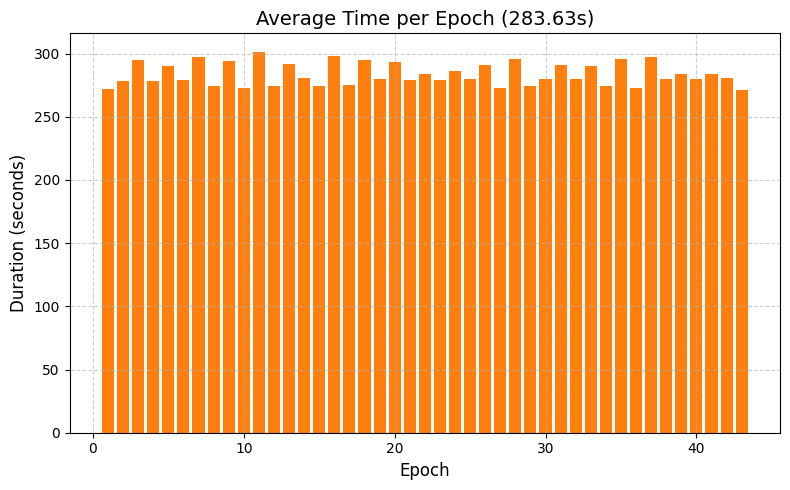

In [101]:
plot_avg_time_per_epoch("./training.logs/outputs_ehrsql_mimic3_t5_base_train.log", 'Average Time per Epoch')

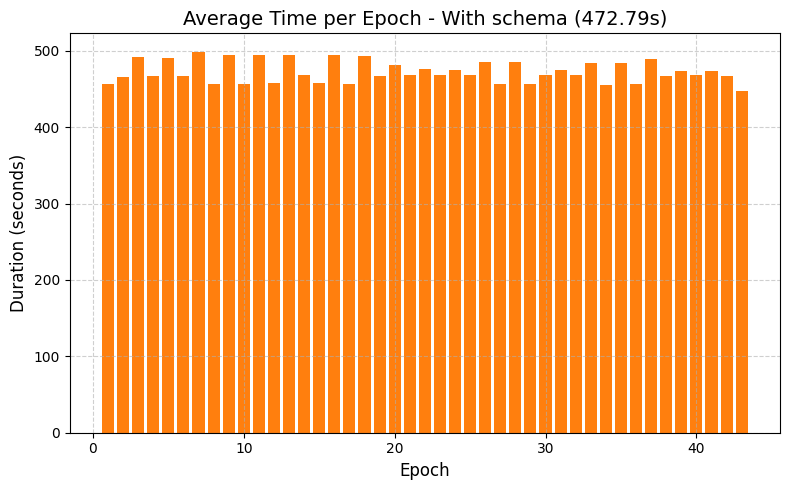

In [102]:
plot_avg_time_per_epoch("./training.logs/outputs_ehrsql_mimic3_t5_base_schema_train.log", 'Average Time per Epoch - With schema')

In [ ]:
def extract_best_train_loss(log__file_path):
    pattern = re.compile(
        r"epoch: (\d+) \(step: (\d+)\) \| train loss: ([\d.]+) \| lr: ([\d.]+)"
    )
    records = []

    # Load and parse the log file
    with open(log__file_path, 'r') as file:
        for line in file:
            match = pattern.search(line)
            if match:
                epoch, step, train_loss, lr = match.groups()
                records.append({
                    'epoch': int(epoch),
                    'step': int(step),
                    'train_loss': float(train_loss),
                    'lr': float(lr)
                })
    
    df = pd.DataFrame(records)

    # Group by epoch, get best train_loss and corresponding step
    sorted_df = df.sort_values(by=['epoch', 'train_loss'])
    best_per_epoch = sorted_df.drop_duplicates(subset='epoch', keep='first')
    best_per_epoch = best_per_epoch[['epoch', 'train_loss', 'step']]
    best_per_epoch = best_per_epoch.rename(columns={'train_loss': 'best_train_loss'})
    best_per_epoch.reset_index(drop=True, inplace=True)
    return best_per_epoch

In [115]:
# Plot learning curve
def plot_loss_curve(best_per_epoch, title):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Best Train Loss
    ax1.plot(best_per_epoch['epoch'], best_per_epoch['best_train_loss'],
             marker='o', linestyle='-', color='blue', label='Best Train Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Best Train Loss', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Add second y-axis for step
    ax2 = ax1.twinx()
    ax2.plot(best_per_epoch['epoch'], best_per_epoch['step'],
             marker='s', linestyle='-', color='orange', label='Step at Best Loss')
    ax2.set_ylabel('Step', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Title and grid
    plt.title(title)
    ax1.grid(linestyle='--', alpha=0.6)
    fig.tight_layout()
    plt.show()

    # plt.figure(figsize=(10, 5))
    # plt.plot(best_per_epoch['epoch'], best_per_epoch['best_train_loss'], marker='o', linestyle='-', color='blue')
    # plt.xlabel('Epoch')
    # plt.ylabel('Best Train Loss')
    # plt.title(title)
    # plt.grid(linestyle='--', alpha=0.6)
    # plt.xticks(best_per_epoch['epoch'])
    # plt.tight_layout()
    # plt.show()


In [109]:
best_per_epoch = extract_best_train_loss("./training.logs/outputs_ehrsql_mimic3_t5_base_train.log")
best_per_epoch.head(10)

,epoch,best_train_loss,step
0,1,0.012208,2300
1,2,0.004708,4550
2,3,0.002552,6650
3,4,0.001511,8800
4,5,0.001010,11100
5,6,0.000646,13350
6,7,0.000444,15650
7,8,0.000336,17600
8,9,0.000297,20350
9,10,0.000228,22450


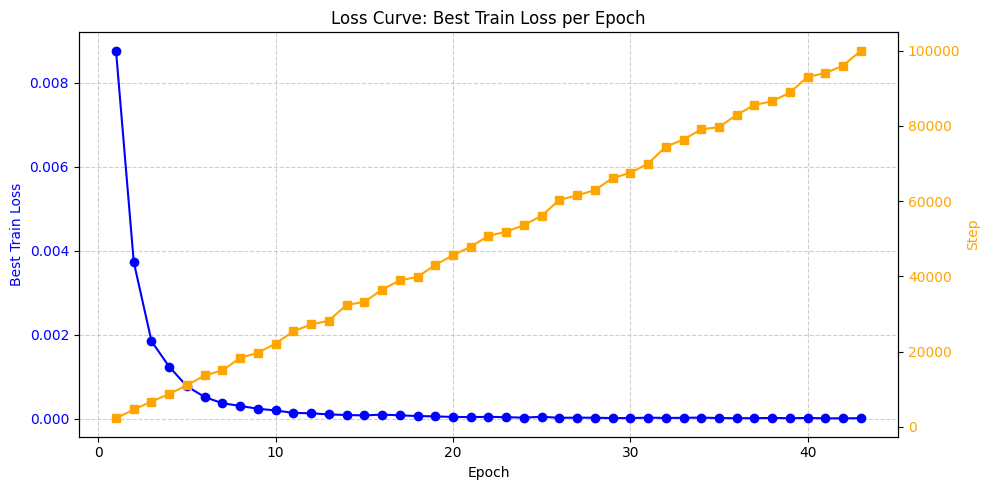

In [116]:
plot_loss_curve(best_per_epoch, 'Loss Curve: Best Train Loss per Epoch')

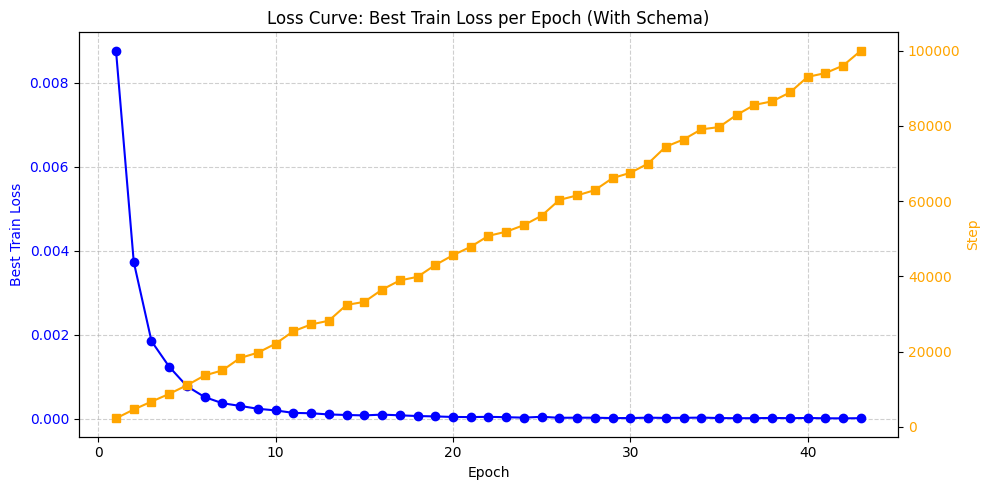

In [117]:
best_per_epoch = extract_best_train_loss("./training.logs/outputs_ehrsql_mimic3_t5_base_schema_train.log")
plot_loss_curve(best_per_epoch, 'Loss Curve: Best Train Loss per Epoch (With Schema)')